In [ ]:
import geopandas as gpd
import pandas as pd

df = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\temporal_data_t100_years2022-2022.parquet")
gdf = gpd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\building_geometries_years2022-2022.parquet")
merged = gdf.join(df.set_index("DOITT_ID"))


In [ ]:
import timm
import torch.nn as nn
from src.custom_models import ScaleMAE

def inspect_model_modules(model, model_name):
    print(f"\n{'='*50}")
    print(f"Inspecting Modules for: {model_name}")
    print(f"{'='*50}")
    
    linear_layers = []
    
    # Iterate through all named modules in the network
    for name, module in model.named_modules():
        # LoRA is typically applied to Linear or Conv2d layers
        if isinstance(module, nn.Linear):
            linear_layers.append(name)
            
    # Filter for keywords we usually target with LoRA
    target_keywords = ["q", "k", "v", "qkv", "fc1", "fc2", "mlp"]
    
    print("\nPotential Target Layers Found:")
    for name in linear_layers:
        if any(keyword in name for keyword in target_keywords):
            print(f"  - {name}")

if __name__ == "__main__":
    # 1. Check the Fallback (Timm ViT-Large)
    print("Loading Fallback...")
    timm_model = timm.create_model("vit_large_patch16_224", pretrained=False)
    inspect_model_modules(timm_model, "Timm ViT-Large Fallback")
    
    # 2. Check the primary ScaleMAE backbone
    print("\nLoading ScaleMAE...")
    try:
        scalemae_model = ScaleMAE(image_size=224, bands=3, kind="reg").backbone.base_model.model
        inspect_model_modules(scalemae_model, "ScaleMAE Backbone")
    except Exception as e:
        print(f"Could not load ScaleMAE for inspection: {e}")


In [7]:
import pandas as pd
import geopandas as gpd

prediction_year = 2016
savename = "scalemae_lr0.0001_size224_y2010-2012-2014-2016-2018-2020-2022-2024_ranknet_mining_lambda_s_05"
# df = pd.read_csv(rf"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\{savename}\{prediction_year}_predictions_test.csv")
# gdf = gpd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\building_geometries_years2010-2024.parquet")

# df = df.set_index("DOITT_ID")
# gdf = gdf.join(df, how="inner")

# # Compute aggregate statistics for each GEOID
# gdf["prediction_tract_mean"] = gdf.groupby("GEOID")["predicted_value"].transform("mean")
# gdf["prediction_tract_std"] = gdf.groupby("GEOID")["predicted_value"].transform("std")

gdf = gpd.read_parquet(rf"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\{savename}\predictions_{prediction_year}.parquet")

In [9]:
gdf

,geometry,Rel_Score,predicted_value,GEOID,year,type
DOITT_ID,,,,,,
753400,"POLYGON ((999101.237 194849.344, 999137.579 19...",-1.920279,-1.0440,36047050700,2016,test
684953,"POLYGON ((1014822.081 249863.892, 1014828.894 ...",-1.348799,-1.4010,36005039100,2016,test
1238079,"POLYGON ((1060797.785 206417.566, 1060794.925 ...",-0.032073,1.2190,36081157102,2016,test
51599,"POLYGON ((1014574.905 260947.84, 1014563.444 2...",0.206205,-0.7725,36005028100,2016,test
773552,"POLYGON ((1034109.964 162396.916, 1034113.886 ...",0.255448,0.7890,36081107201,2016,test
...,...,...,...,...,...,...
1305600,"POLYGON ((1006767.68 199483.145, 1006847.845 1...",-0.800479,-0.4160,36081053502,2016,test
1305568,"POLYGON ((1027408.277 253185.141, 1027408.091 ...",0.084142,-0.4653,36005031200,2016,test
1305579,"POLYGON ((1021905.999 267093.115, 1021938.755 ...",0.571771,1.1770,36005045102,2016,test


In [12]:
gdf[gdf["type"]=="test"][["predicted_value", "Rel_Score"]].corr(method="spearman")

,predicted_value,Rel_Score
predicted_value,1.000000,0.824532
Rel_Score,0.824532,1.000000


Quantile 0: R^2 = 0.8495
Quantile 0: Spearman = 0.8677
Quantile 1: R^2 = 0.7421
Quantile 1: Spearman = 0.8703
Quantile 2: R^2 = 0.5975
Quantile 2: Spearman = 0.8356
Quantile 3: R^2 = 0.5763
Quantile 3: Spearman = 0.7980
Quantile 4: R^2 = 0.3565
Quantile 4: Spearman = 0.6180


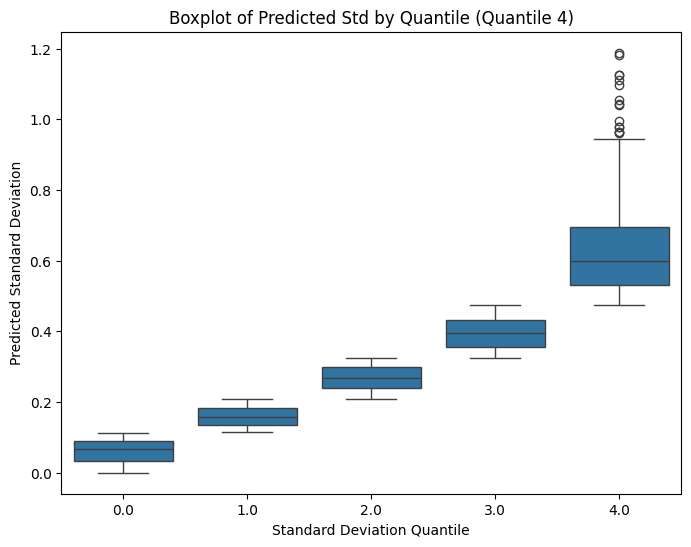

type,dead_zone,test,train,val
std_quantile,,,,
0.0,0.137472,0.046563,0.756098,0.059867
1.0,0.172949,0.057650,0.711752,0.057650
2.0,0.242222,0.115556,0.593333,0.048889
3.0,0.199557,0.093126,0.627494,0.079823
4.0,0.259424,0.106430,0.574279,0.059867


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

gdf_tract = gdf.groupby("GEOID").agg(predicted_value_mean=("predicted_value", "mean"), predicted_std=("predicted_value", "std"), Rel_Score_mean=("Rel_Score", "mean"))
# Merge with tract geometries
tract_geometries = gpd.read_feather(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\tract_splits.feather")
tract_geometries["GEOID"] = tract_geometries["GEOID"].astype(int)
tract_geometries = tract_geometries.set_index("GEOID")
gdf_tract = tract_geometries.join(gdf_tract, how="inner", validate="1:1")

gdf_tract["std_quantile"] = pd.qcut(gdf_tract["predicted_std"], q=5, labels=False)

# Compute correlation at the tract level per quantile
for quantile in range(5):
    subset = gdf_tract[gdf_tract["std_quantile"] == quantile]
    corr = subset[["predicted_value_mean", "Rel_Score_mean"]].corr(method="pearson") ** 2
    print(f"Quantile {quantile}: R^2 = {corr.loc['predicted_value_mean', 'Rel_Score_mean']:.4f}")   
    corr = subset[["predicted_value_mean", "Rel_Score_mean"]].corr(method="spearman")
    print(f"Quantile {quantile}: Spearman = {corr.loc['predicted_value_mean', 'Rel_Score_mean']:.4f}")   

# Create boxplot of standard deviation by quantile
plt.figure(figsize=(8, 6))
sns.boxplot(x="std_quantile", y="predicted_std", data=gdf_tract)
plt.title(f"Boxplot of Predicted Std by Quantile (Quantile {quantile})")
plt.xlabel("Standard Deviation Quantile")
plt.ylabel("Predicted Standard Deviation")
plt.show()

pd.crosstab(gdf_tract["std_quantile"], gdf_tract["type"], normalize="index")

<Axes: >

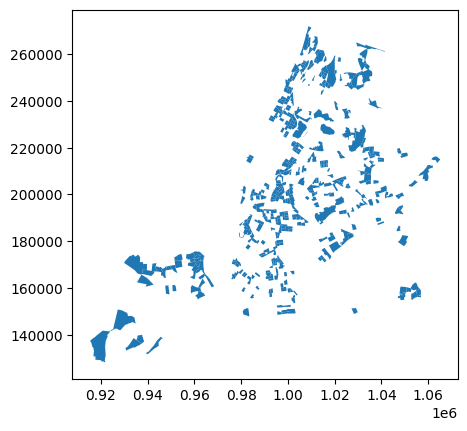

In [14]:
gdf_tract[gdf_tract["std_quantile"] == 4].plot()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Ensure numeric types (in case headers are still present)
df_clean = gdf[gdf["predicted_value"] != "predicted_value"].copy()
df_clean["predicted_value"] = pd.to_numeric(df_clean["predicted_value"])
df_clean["Rel_Score"] = pd.to_numeric(df_clean["Rel_Score"])

import plotly.express as px

# Reset index to ensure DOITT_ID (and any other index) is available as a column for Plotly
fig = px.scatter(
    df_clean.reset_index(),  # <--- Added .reset_index() here
    x="Rel_Score", 
    y="predicted_value",
    hover_data=["GEOID", "year", "DOITT_ID"] if "DOITT_ID" in df_clean.index.names or "DOITT_ID" in df_clean.columns else ["GEOID", "year"],
    title="Aerial Imagery Model: Ground Truth vs. Predictions",
    labels={
        "Rel_Score": "Ground Truth (Relative Income Score)", 
        "predicted_value": "Model Prediction"
    },
    opacity=0.5,
    template="plotly_dark"
)

# Add identity line
min_val = min(df_clean["Rel_Score"].min(), df_clean["predicted_value"].min())
max_val = max(df_clean["Rel_Score"].max(), df_clean["predicted_value"].max())
fig.add_shape(
    type="line", line=dict(dash="dash", color="cyan", width=2),
    x0=min_val, y0=min_val, x1=max_val, y1=max_val
)

fig.show()

In [18]:
import plotly.express as px
import pandas as pd

# 1. Ensure numeric types (in case headers are still present)
df_clean = gdf[gdf["predicted_value"] != "predicted_value"].groupby("GEOID").agg({"predicted_value": "mean", "Rel_Score": "mean"}).reset_index()
df_clean["predicted_value"] = pd.to_numeric(df_clean["predicted_value"])
df_clean["Rel_Score"] = pd.to_numeric(df_clean["Rel_Score"])

import plotly.express as px

# Reset index to ensure DOITT_ID (and any other index) is available as a column for Plotly
fig = px.scatter(
    df_clean.reset_index(),  # <--- Added .reset_index() here
    x="Rel_Score", 
    y="predicted_value",
    hover_data=["GEOID"],
    title="Aerial Imagery Model: Ground Truth vs. Predictions",
    labels={
        "Rel_Score": "Ground Truth (Relative Income Score)", 
        "predicted_value": "Model Prediction"
    },
    opacity=0.5,
    template="plotly_dark"
)

# Add identity line
# min_val = min(df_clean["Rel_Score"].min(), df_clean["predicted_value"].min())
# max_val = max(df_clean["Rel_Score"].max(), df_clean["predicted_value"].max())
# fig.add_shape(
#     type="line", line=dict(dash="dash", color="cyan", width=2),
#     x0=min_val, y0=min_val, x1=max_val, y1=max_val
# )

fig.show()

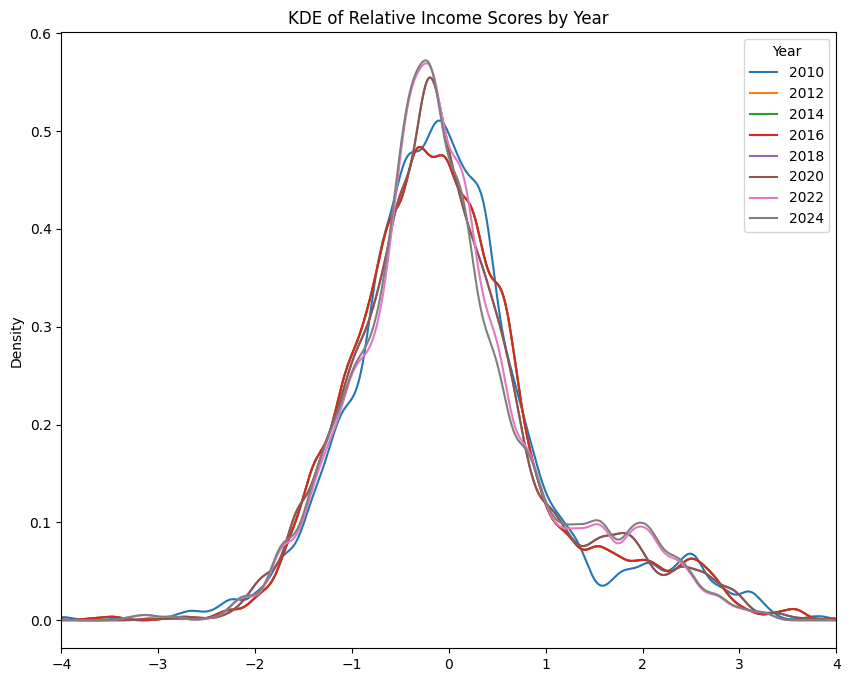

In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

for year in [2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]:
    df = pd.read_parquet(rf"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr0.0001_size224_y2010-2012-2014-2016-2018-2020-2022-2024_ranknet_mining_lambda_s_05\predictions_by_tract_{year}.parquet")
    df["Rel_Score"].plot.kde(bw_method=0.1, ax=ax, label=str(year))

ax.set_xlim(-4, 4)
ax.set_title("KDE of Relative Income Scores by Year")
ax.legend(title="Year")

In [9]:
import geopandas as gpd
import pandas as pd
buildings = gpd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\building_geometries_years2010-2024.parquet")
changes = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr0.0001_size224_y2010-2012-2014-2016-2018-2020-2022-2024_ranknet_mining_lambda_s_05\evaluation\tables\B_intensity_indicators.parquet")
buildings.join(changes.set_index("DOITT_ID"), how="inner").to_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr0.0001_size224_y2010-2012-2014-2016-2018-2020-2022-2024_ranknet_mining_lambda_s_05\evaluation\tables\B_intensity_indicators_with_geometries.parquet")  

In [13]:
changes = gpd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\building_changes.parquet")
splits = gpd.read_feather(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\building_splits.feather")

In [16]:
splits["type"].value_counts()

type
dead_zone               6196060
test                    1708523
val_spatial              549523
val_time                  82869
val_spatial_temporal        437
Name: count, dtype: int64

<Axes: ylabel='Density'>

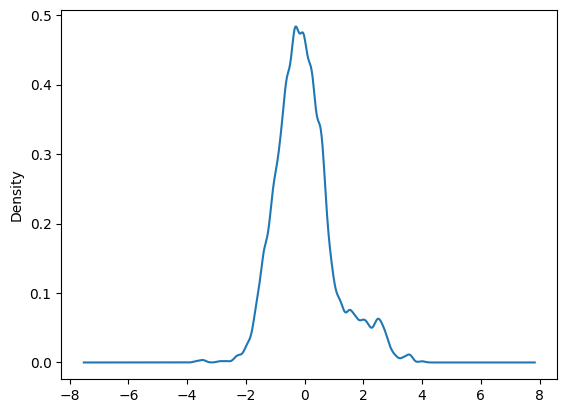

In [15]:
df["Rel_Score"].plot.kde(bw_method=0.1)

In [ ]:
df

In [ ]:
boros = gpd.read_file(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\external\NYC Borough Boundaries\Borough_Boundaries_20260131.geojson")
gdf = gdf.sjoin(boros[["boroname", "geometry"]].to_crs(gdf.crs), predicate="intersects")

In [ ]:
gdf[gdf["type"]=="test"]

In [ ]:
by_tract.corr(method="spearman")

In [ ]:
by_tract = gdf[gdf["type"]=="test"].groupby("GEOID").agg({
    "Rel_Score": "mean",
    "predicted_value": "mean",
})

import plotly.express as px

# Note: trendline="ols" requires the 'statsmodels' package installed
fig = px.scatter(
    by_tract, 
    x="Rel_Score", 
    y="predicted_value", 
    trendline="ols",
    title="Relative Score vs Predicted Value by Borough",
    labels={
        "Rel_Score": "Actual Relative Score",
        "predicted_value": "Predicted Value"
    }
)
# Increase height for better visibility of the trendline
fig.update_layout(height=1000)


# 2. Determine the range for the 45-degree line
# (This ensures the line covers the full extent of the data)
min_val = min(by_tract["Rel_Score"].min(), by_tract["predicted_value"].min())
max_val = max(by_tract["Rel_Score"].max(), by_tract["predicted_value"].max())
# 3. Add the 45-degree line shape
fig.add_shape(
    type="line",
    x0=min_val, y0=min_val,
    x1=max_val, y1=max_val,
    line=dict(color="Gray", width=2, dash="dash"),
    layer="below" # Keeps the data points on top
)


fig.show()


In [ ]:
ds

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the dataset
# chunks='auto' ensures Dask handles the 200GB file gracefully
ds = xr.open_zarr(r"E:\Datasets\Imagenes Satelitales\New York City\nyc_2022.zarr", chunks='auto')

data = ds['value'] # Replace with your variable name

# Check your dimensions! 
# Most Zarrs use (band, y, x). Let's assume that for this example.
# We want to skip pixels in Y and X, but keep ALL bands (R, G, B).
ny, nx = data.sizes['y'], data.sizes['x']

step_y = max(1, ny // 100)
step_x = max(1, nx // 100)

# Slice: ':' for bands (keep all), slice for y and x
# If your bands are the first dimension:
small_subset = data.isel(
    y=slice(0, None, step_y), 
    x=slice(0, None, step_x),
    band=slice(0, 3) # Ensure we only get R, G, and B
)

# Plotting
plt.figure(figsize=(10, 10))

# xarray's imshow is smart: if it sees a dimension of size 3, 
# it treats it as RGB. You just need to tell it which dim is the RGB one.
small_subset.plot.imshow(rgb='band') 

plt.title("Quick RGB Look")
plt.show()

In [ ]:
small_subset = small_subset.to_numpy()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.imshow(np.moveaxis(np.nan_to_num(small_subset, 0), 0, -1))

In [ ]:
ny // 100

In [ ]:
import pandas as pd
import geopandas as gpd

df = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\temporal_data_t100_years2022-2022.parquet")
gdf = gpd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\building_geometries_years2022-2022.parquet")

df = df[df["year"]==2022]
df = df.set_index("DOITT_ID")
gdf = gdf.join(df, how="inner")
gdf.to_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\source_2022.parquet")

In [ ]:
df

In [ ]:
merged.to_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\test.parquet")

In [ ]:
from src.utils.paths import PROJECT_ROOT, DATA_DIR, EXTERNAL_DATA_DIR, IMAGERY_ROOT, RAW_DATA_DIR

In [ ]:
import os
# 1. Force TensorFlow to use the legacy Keras 2 engine for this script
os.environ["TF_USE_LEGACY_KERAS"] = "1"



# 2. Define your paths
model_folder = "/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/raw/EfficientNetV2S Trained Model Weights/effnet_v2S_lr0.0001_size128_y2013-2018-2022_stack1-4_141"

# We use .h5 here because Keras 2 excels at saving it, and Keras 3 excels at reading it.
output_filepath = "/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/raw/EfficientNetV2S Trained Model Weights/plos_weights.h5"

print(f"Loading legacy model from: {model_folder}")

try:
    # 3. Load the model using Keras 2
    model = tf.keras.models.load_model(model_folder)
    print("Legacy model loaded successfully!")
    
    # 4. Save it as an HDF5 file
    model.save(output_filepath)
    print(f"Success! Bridge model saved to: {output_filepath}")

except Exception as e:
    print(f"An error occurred during conversion:\n{e}")

In [ ]:
model.summary()

In [ ]:
import pandas as pd

df = pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/val_datasets/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling_val_dataframe.feather")
df

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
from src import build_dataset
gdf = build_dataset.load_income_dataset()
gdf

In [ ]:
import numpy as np
gdf["avg_hh_inc"].apply(lambda x: np.log(x)).plot.hist(bins=100)

In [ ]:
df

In [ ]:
import os
os.listdir()

In [ ]:
import re
import shutil
# 1. Define your paths
source_folder = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling"  # Change this to the path where your files are
target_folder = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/archive"

# Create the target folder if it doesn't exist
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

# 2. Get all files in the directory
files = os.listdir(source_folder)

# 3. Regular expression to find the number just before '.keras'
# It looks for digits (\d+) followed by '.keras' at the end of the string ($)
pattern = re.compile(r'_(\d+)\.keras$')

moved_count = 0

for filename in files:
    match = pattern.search(filename)
    
    if match:
        # Extract the number and convert to integer
        file_index = int(match.group(1))
        
        # Check if it is NOT a multiple of 5
        if file_index % 5 != 0:
            source_path = os.path.join(source_folder, filename)
            target_path = os.path.join(target_folder, filename)
            print(f"Moving '{filename}' to '{target_folder}'")
            # Move the file
            shutil.move(source_path, target_path)
            moved_count += 1

print(f"Cleanup complete. Moved {moved_count} files to '{target_folder}'.")

In [ ]:
import pandas as pd
from src import build_dataset
df = pd.read_csv(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/2022_predictions_effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.csv")
gdf = build_dataset.load_income_dataset()
gdf = gdf.reset_index(drop=True)
gdf = gdf.join(df, how="inner")
# Drop black predictions
gdf = gdf[gdf.predicted_value != gdf.predicted_value.mode().item()]
# gdf.to_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/2022_predictions_effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.parquet")

gdf['geometry'] = gdf.geometry.buffer(0)
gdf_by_census_tract = gdf.dissolve(
    "GEOID", 
    aggfunc={'var': 'mean', 'predicted_value': 'mean'}
)
gdf_by_census_tract.to_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/2022_predictions_by_tract_effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling.parquet")

In [ ]:
from src import build_dataset

gdf = build_dataset.split_train_test(gdf)

In [ ]:


def plot_random_cached_images_from_shards(train_cache_dir, val_cache_dir, n=5, seed=None):
    """Plot n random images from train/val cyclic cache shard files with labels."""
    import matplotlib.pyplot as plt
    from pathlib import Path
    import torch
    import numpy as np

    def _load_cache(cache_dir):
        cache_dir = Path(cache_dir)
        assert cache_dir.exists(), f"Cache directory not found: {cache_dir}"

        images = []
        labels = []
        shards = sorted(cache_dir.glob('shard_*.pt'))
        for shard in shards:
            data = torch.load(shard, weights_only=True)
            if data['images'].numel() == 0:
                continue
            images.append(data['images'])
            labels.append(data['labels'])

        if len(images) == 0:
            raise RuntimeError(f"No valid images found in cache {cache_dir}")

        images = torch.cat(images, dim=0)
        labels = torch.cat(labels, dim=0)
        return images, labels

    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    train_images, train_labels = _load_cache(train_cache_dir)
    val_images, val_labels = _load_cache(val_cache_dir)

    def _plot_group(imgs, lbls, ax_row):
        idxs = np.random.choice(len(imgs), min(n, len(imgs)), replace=False)
        for col, i in enumerate(idxs):
            img = imgs[i]
            lbl = lbls[i].item() if isinstance(lbls[i], torch.Tensor) else float(lbls[i])
            img_np = img.cpu().numpy() if isinstance(img, torch.Tensor) else np.asarray(img)
            img_np = np.transpose(img_np, (1, 2, 0))
            if img_np.shape[2] == 4:
                img_np = img_np[:, :, :3]
            if img_np.dtype == np.uint8:
                img_np = img_np.astype(np.float32) / 255.0
            elif img_np.max() > 1.0:
                img_np = img_np / img_np.max()

            ax = ax_row[col]
            ax.imshow(img_np)
            ax.axis('off')
            ax.set_title(f"{lbl:.3f}")

    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    fig.suptitle('Random cached images from train (top) and val (bottom)')

    _plot_group(train_images, train_labels, axes[0])
    _plot_group(val_images, val_labels, axes[1])

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("cache_inspection.png", dpi=450)


# Example usage:
plot_random_cached_images_from_shards(
    train_cache_dir='/home/abbatenicolas/data/cache/train_cache',
    val_cache_dir='/home/abbatenicolas/data/cache/val_cache',
    n=5,
    seed=42
)

In [ ]:
gdf_by_census_tract = gdf.dissolve(
    "GEOID", 
    aggfunc={'boroname': 'first', 'type': 'first', 'var': 'mean', 'predicted_value': 'mean'}
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

df = pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/ny_tracts_panel_2009_2014_2019_2024.feather")
df_rel_scores = df[["Rel_Score_2009", "Rel_Score_2014", "Rel_Score_2019", "Rel_Score_2024"]]
ax = df_rel_scores.plot(kind='kde')
means = df_rel_scores.median()
# Add means to the plot
ax.axvline(means["Rel_Score_2009"], color='blue', linestyle='--', label='Mean 2009')
ax.axvline(means["Rel_Score_2014"], color='orange', linestyle='--', label='Mean 2014')
ax.axvline(means["Rel_Score_2019"], color='green', linestyle='--', label='Mean 2019')
ax.axvline(means["Rel_Score_2024"], color='red', linestyle='--', label='Mean 2024')
ax.set_xlim(-2, 2)

In [ ]:
temporal_df

In [ ]:
building_historical = gpd.read_file(BUILDINGS_DATASET_DIR / "BUILDING_HISTORIC_view_4222244593352533104.geojson")
building_historical

In [ ]:
building_historical[building_historical.DOITT_ID.duplicated(keep=False)].sort_values("DOITT_ID")

In [ ]:
gdf

In [ ]:
df

In [ ]:
import seaborn as sns
df_plot = df[["geoid_2024", "Rel_Score_2009", "Rel_Score_2014", "Rel_Score_2019", "Rel_Score_2024", "Valid_Structural_Change"]]
# Put in long format for seaborn
df_plot = df_plot.melt(id_vars=["geoid_2024", "Valid_Structural_Change"], var_name="Year", value_name="Rel_Score")
df_plot["Year"] = df_plot["Year"].str.replace("Rel_Score_", "")
df_plot.sort_values(["geoid_2024", "Year"], inplace=True)
sns.relplot(data=df_plot.head(200), x="Year", y="Rel_Score", alpha=0.5, kind="line", hue="geoid_2024", col="Valid_Structural_Change", legend=False)

In [ ]:
import pandas as pd

commute_times = pd.read_csv(r"/mnt/c/Users/abbat/Downloads/NTAD_Travel_Time_to_Work_-191947857899151027.csv")

In [ ]:
gdf['geometry'] = gdf.geometry.buffer(0)
gdf["predicted_value_tract"] = gdf.groupby("GEOID").predicted_value.transform("mean")



In [ ]:
gdf[(gdf["type"] == "test") & (gdf["boroname"] == "Bronx")].plot()

In [ ]:
gdf["sq_diff"] = (gdf["predicted_value"] - gdf["var"]) ** 2
gdf_by_census_tract["sq_diff_tract"] = (gdf_by_census_tract["predicted_value"] - gdf_by_census_tract["var"]) ** 2

# Compute R2 per boroname by sq_diff and sq_diff_tract
# gdf.groupby("boroname").apply(lambda x: 1 - (x["sq_diff"].sum() / ((x["var"] - x["var"].mean()) ** 2).sum()))
table = gdf_by_census_tract.groupby(["boroname", "type"]).apply(lambda x: (1 - (x["sq_diff_tract"].sum() / ((x["var"] - x["var"].mean()) ** 2).sum()), x["sq_diff_tract"].shape[0] ))

In [ ]:
table

In [ ]:
import pandas as pd

# 1. Convert Series to DataFrame and reset index so 'boroname' and 'type' become columns
table.name = "R2_and_n"  # Name the Series for clarity when converting to DataFrame
df = table.to_frame().reset_index()

# 2. Split the tuple column ("R2_and_n") into two distinct columns
# We use .tolist() on the column to easily create a new DataFrame structure
df[['R2', 'n']] = pd.DataFrame(df['R2_and_n'].tolist(), index=df.index)

# 3. Drop the original tuple column (optional, but cleaner)
df = df.drop(columns=['R2_and_n'])

# 4. Pivot the table
result = df.pivot(index="boroname", columns="type", values=["R2", "n"])

print(result)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
boroughs = ['Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
r2_test = [0.157029, 0.600607, -0.014487, 0.300580]
r2_train = [0.757855, 0.689397, 0.843702, 0.863781]
n_test = [139, 65, 216, 36]
n_train = [620, 220, 467, 83]

x = np.arange(len(boroughs))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. R^2 Score Plot
ax1.bar(x - width/2, r2_train, width, label='Train', color='skyblue', edgecolor='black')
ax1.bar(x + width/2, r2_test, width, label='Test', color='salmon', edgecolor='black')

ax1.set_ylabel('$R^2$ Score')
ax1.set_title('$R^2$ Scores by Borough (Train vs Test)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.8) # Zero line for reference

# 2. Sample Size (n) Plot
rects_n_train = ax2.bar(x - width/2, n_train, width, label='Train $n$', color='lightgreen', edgecolor='black')
rects_n_test = ax2.bar(x + width/2, n_test, width, label='Test $n$', color='orange', edgecolor='black')

ax2.set_ylabel('Sample Size ($n$)')
ax2.set_title('Sample Sizes by Borough (Train vs Test)')
ax2.set_xticks(x)
ax2.set_xticklabels(boroughs)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Helper function to add labels on top of bars
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects_n_train, ax2)
autolabel(rects_n_test, ax2)

plt.tight_layout()
plt.show()

In [ ]:
# Get the distribution of the target variable
# I want the 10 percentiles

# gdf["var"].describe()
gdf["var"].quantile([0.1 * i for i in range(1, 11)])

In [ ]:
from src import build_dataset

datasets, extents = build_dataset.load_satellite_datasets(year=2014, stretch=False, engine="zarr")

In [ ]:
import numpy as np
import geopandas as gpd

def get_test_area_from_file(filename = "Test_NYC_Area.parquet"):
    test = gpd.read_parquet(RAW_DATA_DIR / filename)
    print(test.crs)
    test_polygon = test.dissolve().geometry.iloc[0]
    return test_polygon

def split_train_test_polygon(gdf, test_polygon, buffer=0):
    """
    Splits the GeoDataFrame into 'train' and 'test' based on a test_polygon.
    
    Logic:
    - TEST:  Geometry is strictly INSIDE the test_polygon.
    - TRAIN: Geometry is strictly OUTSIDE the (test_polygon + buffer).
    - DROP:  Geometry overlaps the border or falls within the buffer zone.
    """
    
    # Initialize column with NaNs
    gdf["type"] = np.nan

    # 1. Identify TEST rows
    # "within" checks if the feature is fully contained inside the test polygon
    test_mask = gdf.geometry.within(test_polygon)
    gdf.loc[test_mask, "type"] = "test"

    # 2. Identify TRAIN rows
    # We buffer the test polygon to create the "exclusion zone"
    # "disjoint" checks if the feature has absolutely no overlap with the buffered zone
    exclusion_zone = test_polygon.buffer(buffer)
    train_mask = gdf.geometry.disjoint(exclusion_zone)
    gdf.loc[train_mask, "type"] = "train"

    # 3. Calculate and Print Stats
    test_size = gdf[gdf["type"] == "test"].shape[0]
    train_size = gdf[gdf["type"] == "train"].shape[0]
    invalid_size = gdf[gdf["type"].isna()].shape[0]
    total_size = gdf.shape[0]

    print(
        "",
        f"Size of test dataset: {test_size/total_size*100:.2f}% ({test_size} features)",
        f"Size of train dataset: {train_size/total_size*100:.2f}% ({train_size} features)",
        f"Deleted images due to train/test overlapping: {invalid_size/total_size*100:.2f}% ({invalid_size} features)",
        sep="\n",
    )

    return gdf

gdf = build_dataset.load_income_dataset(variable="avg_hh_inc", trim=False)
test_polygon = get_test_area_from_file()
split_train_test_polygon(gdf, test_polygon, buffer=500)

In [ ]:
from pyproj import Transformer
import math

from pyproj import CRS

def projected_units_to_meters(value: float, epsg_code: int) -> float:
    """
    Converts a value from the native units of a projected CRS into meters.
    
    Args:
        value (float): The distance in the native CRS units (e.g., 0.5)
        epsg_code (int): The EPSG code of the projected coordinate system
        
    Returns:
        float: The exact equivalent distance in meters.
    """
    crs = CRS.from_epsg(epsg_code)
    
    # 1. Safety check: ensure the CRS is projected (linear), not geographic (angular/degrees)
    if crs.is_geographic:
        raise ValueError(
            f"EPSG:{epsg_code} is a geographic CRS ({crs.name}). "
            "Its units are degrees, which do not have a constant meter length. "
            "Please provide a Projected CRS."
        )
        
    # 2. Fetch the exact conversion factor to meters for this specific CRS
    # axis_info[0] looks at the first spatial axis (usually Easting/X)
    conversion_factor = crs.axis_info[0].unit_conversion_factor
    unit_name = crs.axis_info[0].unit_name
    
    print(f"EPSG:{epsg_code} native unit is '{unit_name}'.")
    print(f"Conversion factor to meters: 1 {unit_name} = {conversion_factor} meters.")
    
    # 3. Calculate and return
    return value * conversion_factor

# --- Examples ---

if __name__ == "__main__":
    
    # Your use case: 0.5 units in EPSG:6539 (NAD83 / New York Long Island)
    # Native unit: US Survey Foot
    meters_ny = projected_units_to_meters(0.5, 6539)
    print(f"Result: {meters_ny} meters\n")
    
    # Another use case: 0.5 units in EPSG:32618 (WGS 84 / UTM zone 18N)
    # Native unit: Metre
    meters_utm = projected_units_to_meters(0.5, 32618)
    print(f"Result: {meters_utm} meters\n")

In [ ]:
meters_ny

In [ ]:
import numpy as np
import xarray as xr
ds = xr.open_zarr(
    "/home/abbatenicolas/data/nyc_2022.zarr"
)

meters_buffer = 150
projected_units_per_pixel = 0.5
meters_per_pixel = projected_units_to_meters(projected_units_per_pixel, 6539) 
buffer_in_pixels = math.ceil(meters_buffer / meters_per_pixel)

x_array = ds.x.to_numpy()
y_array = ds.y.to_numpy()
# Sample 2 random coordinates from the dataset

x = np.random.choice(x_array)
y = np.random.choice(y_array)
image = ds.sel(x=slice(x, x + buffer_in_pixels), y=slice(y + buffer_in_pixels, y))
image = np.moveaxis(image.to_array().values[0,:3,:,:], 0, -1).astype(np.uint8)
image

In [ ]:
import pandas as pd

df = pd.read_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/nyc_buildings_with_sae.parquet")
df

In [ ]:
def call_tile_xarray(ds, bboxes):
    xmin, ymin, xmax, ymax = bboxes[np.random.choice(len(bboxes))]
    tile = ds.rio.clip_box(
        minx=xmin,
        miny=ymin,
        maxx=xmax,
        maxy=ymax,
        crs="EPSG:6539"  # CRS of your bbox coords (can differ from the dataset's CRS)
    )
    return tile

call_tile_xarray(ds, bboxes)

In [ ]:
def find_index_of_point_in_dataset(xvalues, yvalues, point):
    # Find the rearest raster of this random point
    x, y = point
    idx_x = np.searchsorted(xvalues, x, side="left", sorter=None)
    idx_y = np.searchsorted(
        -yvalues, -y, side="left", sorter=None
    )  # The y array is inverted! https://stackoverflow.com/questions/43095739/numpy-searchsorted-descending-order
    return idx_x, idx_y

def call_tile_zarr(zarr_array, x_values, y_values, df):
    xmin, ymin, xmax, ymax = bboxes[np.random.choice(len(bboxes))]
    idx_xmin, idx_ymin = find_index_of_point_in_dataset(x_values, y_values, (xmin, ymin))
    idx_xmax, idx_ymax = find_index_of_point_in_dataset(x_values, y_values, (xmax, ymax))
    tile = zarr_array[:, idx_ymax:idx_ymin, idx_xmin:idx_xmax]
    return tile

bboxes = df[["bbox_minx", "bbox_miny", "bbox_maxx", "bbox_maxy"]].to_numpy()
zarr_file = zarr.open(r"/home/abbatenicolas/data/nyc_2016.zarr", mode="r")
x_values = zarr_file["x"][:] # Zarr uses dictionary-style access
y_values = zarr_file["y"][:]
call_tile_zarr(zarr_file["value"], x_values, y_values, bboxes)

In [ ]:
import zarr
import numpy as np

def precompute_all_indices(x_values, y_values, bboxes):
    """
    Vectorized: converts all CRS bboxes → pixel index tuples in one shot.
    bboxes: np.ndarray of shape (N, 4) → [xmin, ymin, xmax, ymax]
    """
    xmins, ymins, xmaxs, ymaxs = bboxes[:,0], bboxes[:,1], bboxes[:,2], bboxes[:,3]

    # x is ascending
    col_starts = np.searchsorted(x_values, xmins, side="left")   # include xmin
    col_stops  = np.searchsorted(x_values, xmaxs, side="right")  # include xmax

    # y is descending — negate to use searchsorted
    neg_y = -y_values
    row_starts = np.searchsorted(neg_y, -ymaxs, side="left")   # ymax → top row (small idx)
    row_stops  = np.searchsorted(neg_y, -ymins, side="right")  # ymin → bottom row (large idx)

    return np.array([row_starts, row_stops, col_starts, col_stops]).T


def load_tile(zarr_array, idx):
    tile = zarr_array[:, row["row_start"]:row["row_stop"], row["col_start"]:row["col_stop"]]
    return tile


# --- One-time setup ---
zarr_file  = zarr.open("/home/abbatenicolas/data/nyc_2016.zarr", mode="r")
x_values   = zarr_file["x"][:]
y_values   = zarr_file["y"][:]
bboxes     = df[["bbox_minx", "bbox_miny", "bbox_maxx", "bbox_maxy"]].to_numpy()
zarr_array = zarr_file["value"]

# Precompute ALL indices once — O(N log M), fully vectorized
all_indices = precompute_all_indices(x_values, y_values, bboxes)
all_indices.shape

In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, box
import math

def random_point_from_geometry(polygon, inside=True):
    """Generates a random point within the bounds of a Polygon."""
    # Get bounds of the shapefile's polygon
    (minx, miny, maxx, maxy) = polygon.bounds

    # Loop until finding a random point inside the polygon
    while True:
        # generate random data within the bounds
        x = np.random.uniform(minx, maxx, 1)
        y = np.random.uniform(miny, maxy, 1)
        
        # Shapely Point requires scalars, so we pass x[0] and y[0]
        point = Point(x[0], y[0])
        if inside:
            if polygon.contains(point):
                return x[0], y[0]
        else:
            return x[0], y[0]

def create_evaluation_area(gdf, k_max, k_min, eval_fraction=0.05):
    """
    Creates an evaluation area consisting of random square bounding boxes 
    until a certain percentage of unique GEOIDs are intersected.
    
    Parameters:
    - gdf: GeoDataFrame containing the geometries and a 'GEOID' column.
    - k_max: Maximum radius (half-side of the square) in the CRS units.
    - k_min: Minimum radius (half-side of the square) in the CRS units.
    - eval_fraction: Fraction of unique GEOIDs to capture (default 0.05 / 5%).
    
    Returns:
    - GeoDataFrame of the generated evaluation area (the bounding boxes).
    """
    # 1. Determine the target number of unique GEOIDs
    unique_geoids = set(gdf['geoid_2024'].unique())
    target_count = math.ceil(len(unique_geoids) * eval_fraction)
    
    captured_geoids = set()
    evaluation_bboxes = []
    
    # Pre-calculate areas to weight our random polygon selection 
    # (this ensures uniform spatial sampling without doing a costly union_all())
    areas = gdf.geometry.area
    area_probs = areas / areas.sum()
    
    print(f"Targeting {target_count} unique GEOIDs out of {len(unique_geoids)} ({eval_fraction*100}%)...")

    # Repeat steps 1 to 3 until the threshold is met
    while len(captured_geoids) < target_count:
        
        # Step 1: Sample a random point inside the GeoDataFrame
        # Randomly choose a row's geometry, weighted by its area
        random_idx = np.random.choice(gdf.index, p=area_probs)
        chosen_polygon = gdf.loc[random_idx].geometry
        
        # Use the provided function to get a point inside that polygon
        px, py = random_point_from_geometry(chosen_polygon, inside=False)
        
        # Step 2: Create a bbox of a random size up to radius k
        # Generating a random radius k_min<r<k_max to avoid zero-sized boxes
        r = np.random.uniform(k_min, k_max) 
        minx, miny = px - r, py - r
        maxx, maxy = px + r, py + r
        
        current_bbox = box(minx, miny, maxx, maxy)
        
        # Step 3: Compute how many different GEOIDs intersect with that bbox
        # gdf.intersects() uses a spatial index internally, so it's very fast
        intersecting_rows = gdf[gdf.intersects(current_bbox)]
        current_geoids = set(intersecting_rows['geoid_2024'].unique())
        
        # Update our tracking variables
        captured_geoids.update(current_geoids)
        evaluation_bboxes.append(current_bbox)
        
    print(f"Success! Captured {len(captured_geoids)} GEOIDs using {len(evaluation_bboxes)} bounding boxes.")
    
    # Return the polygons that define the evaluation area as a new GeoDataFrame
    eval_area_gdf = gpd.GeoDataFrame(geometry=evaluation_bboxes, crs=gdf.crs)
    
    return eval_area_gdf

def create_dead_zone(eval_area_gdf, buffer_distance):
    """
    Creates a dead zone by buffering the evaluation area geometries to prevent spatial leakage.
    
    Parameters:
    - eval_area_gdf: GeoDataFrame containing the evaluation areas.
    - buffer_distance: Distance to buffer the areas in the native CRS units.
    
    Returns:
    - GeoDataFrame representing the dissolved dead zone.
    """
    # 1. Buffer the geometries by the specified distance
    buffered_geometries = eval_area_gdf.geometry.buffer(buffer_distance)
    
    # 2. Dissolve overlapping buffers into a single MultiPolygon. 
    # This optimizes future spatial operations (like 'disjoint' or 'intersects')
    dissolved_geometry = buffered_geometries.union_all()
    
    # 3. Return as a new GeoDataFrame
    dead_zone_gdf = gpd.GeoDataFrame(geometry=[dissolved_geometry], crs=eval_area_gdf.crs)
    
    return dead_zone_gdf


def create_stratified_evaluation_area(gdf, k_max, k_min, stratify_cols, eval_fraction=0.1):
    """
    Creates an evaluation area by generating bounding boxes, stratifying the targets
    based on specified columns (e.g., ['boroname', 'income_quintile']).
    """
    captured_geoids = set()
    evaluation_bboxes = []
    
    # Create groups based on your stratification columns
    # We use dropna=False so any tracts with missing data aren't entirely ignored
    groups = gdf.groupby(stratify_cols, dropna=False)
    
    print(f"Stratifying across {len(groups)} unique groups...")

    for name, group in groups:
        # 1. Determine the target number of GEOIDs for THIS specific group
        unique_group_geoids = set(group['geoid_2024'].unique())
        target_count = math.ceil(len(unique_group_geoids) * eval_fraction)
        
        if target_count == 0:
            continue
            
        # Pre-calculate area probabilities for this specific group
        areas = group.geometry.area
        if areas.sum() == 0:
            continue
        area_probs = areas / areas.sum()
        
        # Check how many GEOIDs from this group have ALREADY been captured 
        # by bounding boxes generated for previous groups
        group_captured = len(unique_group_geoids.intersection(captured_geoids))
        
        # 2. Seed boxes inside this group until its specific target is met
        while group_captured < target_count:
            
            # Step 1: Sample a random point strictly inside this group
            random_idx = np.random.choice(group.index, p=area_probs)
            chosen_polygon = group.loc[random_idx].geometry
            
            px, py = random_point_from_geometry(chosen_polygon, inside=True)
            
            # Step 2: Create bbox
            r = np.random.uniform(k_min, k_max) 
            minx, miny = px - r, py - r
            maxx, maxy = px + r, py + r
            current_bbox = box(minx, miny, maxx, maxy)
            
            # Step 3: Find ALL intersecting rows across the ENTIRE gdf
            # (Because a box seeded here might capture neighboring tracts from other groups)
            within_tracts = gdf[gdf.geometry.within(current_bbox)]
            if within_tracts.empty:
                continue

            current_geoids = set(within_tracts['geoid_2024'].unique())
            
            captured_geoids.update(current_geoids)
            evaluation_bboxes.append(current_bbox)
            
            # Update how many of THIS group's tracts are now captured
            group_captured = len(unique_group_geoids.intersection(captured_geoids))
            
    print(f"Success! Captured {len(captured_geoids)} total GEOIDs using {len(evaluation_bboxes)} bounding boxes.")
    
    eval_area_gdf = gpd.GeoDataFrame(geometry=evaluation_bboxes, crs=gdf.crs)
    return eval_area_gdf

def remove_dead_zone_polygons(gdf, dead_zone_gdf):
    """
    Removes any polygons in the main GeoDataFrame that intersect with the dead zone.
    
    Parameters:
    - gdf: The main GeoDataFrame (e.g., your census tracts).
    - dead_zone_gdf: The GeoDataFrame representing the buffer/dead zone.
    
    Returns:
    - A new GeoDataFrame containing only the polygons that are completely 
      outside (disjoint from) the dead zone.
    """
    # Combine the dead zone into a single geometry for efficient comparison
    dead_zone_geom = dead_zone_gdf.union_all()
    
    # Keep only rows where the geometry does NOT intersect the dead zone
    # Using ~ (NOT) with intersects takes advantage of GeoPandas' spatial indexing
    training_gdf = gdf[~gdf.intersects(dead_zone_geom)].copy()
    
    # Optional: Reset the index for the new dataframe
    training_gdf = training_gdf.reset_index(drop=True)
    
    print(f"Original size: {len(gdf)} tracts | Training size: {len(training_gdf)} tracts | Removed: {len(gdf) - len(training_gdf)}")
    
    return training_gdf

def plot_train_test_split(gdf, test_area, dead_zone_gdf):
    ax = gdf.plot(figsize=(20,20))
    dead_zone_gdf.plot(ax=ax, color="orange", alpha=0.4, label="Dead Zone")
    # Plot Evaluation Area (Red boxes)
    test_area.plot(ax=ax, color="red", alpha=0.7, label="Eval Area")
    gdf[gdf["type"] == "train"].plot(ax=ax, color="green", label="Train Polygons")
    gdf[gdf["type"] == "test"].plot(ax=ax, color="orange", label="Test Polygons")
    plt.legend()
    plt.title("Train/Test Split with Evaluation Area and Dead Zone")
    plt.show()

from src import geo_utils
from src.utils import paths
gdf = gpd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/ny_tracts_panel_2009_2014_2019_2024.feather").to_crs(epsg=6539)
boros = gpd.read_file(paths.EXTERNAL_DATA_DIR / "NYC Borough Boundaries" / "Borough_Boundaries_20260131.geojson").to_crs(epsg=6539)

# Add quintiles and boroname to gdf for later tabulation of test area coverage by borough and income quintile
gdf = gdf.sjoin(boros[["boroname", "geometry"]], how="left", predicate="intersects").drop(columns=["index_right"])
gdf["income_quintile"] = pd.qcut(gdf["Rel_Score_2024"], q=5, labels=False)
gdf = gdf.dropna(subset=["income_quintile"]).reset_index(drop=True)

k_min = geo_utils.meters_to_projected_units(1000, epsg_code=6539)  # Minimum half-side of the square in CRS units (e.g., meters)
k_max = geo_utils.meters_to_projected_units(1500, epsg_code=6539)  # Maximum half-side of the square in CRS units (e.g., meters)
dead_zone_buffer = geo_utils.meters_to_projected_units(100, epsg_code=6539) # e.g., 150m dead zone



# Compute
test_area = create_stratified_evaluation_area(gdf, k_min=k_min, k_max=k_max, stratify_cols=["income_quintile"], eval_fraction=0.05)
dead_zone_gdf = create_dead_zone(test_area, buffer_distance=dead_zone_buffer)
train_area = remove_dead_zone_polygons(gdf, dead_zone_gdf)

# Create gdf columns for train/test/dead_zone assignment
gdf["type"] = np.where(gdf.geometry.within(test_area.union_all()), "test", 
                np.where(gdf.geometry.intersects(dead_zone_gdf.union_all()), "dead_zone", "train"))
total_train = (gdf["type"] == "train").sum()
total_test = (gdf["type"] == "test").sum()
total_dead_zone = (gdf["type"] == "dead_zone").sum()
total_lost = len(gdf) - total_train - total_test
print(f"Final dataset sizes: Train={total_train} tracts | Test={total_test} tracts | Dead Zone={total_dead_zone} polygons | Lost={total_lost} polygons ({total_lost/len(gdf)*100:.2f}% of total)")

# Tabulate test_area coverage by borough and income quintile
gdf["in_test_area"] = gdf.geometry.within(test_area.union_all())
coverage_table = gdf.groupby(["income_quintile"])["in_test_area"].mean()#.unstack(fill_value=0)
print("Test Area Coverage by Borough and Income Quintile:")
print(coverage_table)

plot_train_test_split(gdf, test_area, dead_zone_gdf)

In [ ]:
total_train_k = []
total_test_k = []
total_dead_zone_k = []

for k in range(0, 4000, 500):

    k_min = geo_utils.meters_to_projected_units(k, epsg_code=6539)  # Minimum half-side of the square in CRS units (e.g., meters)
    k_max = geo_utils.meters_to_projected_units(k+500, epsg_code=6539)  # Maximum half-side of the square in CRS units (e.g., meters)
    dead_zone_buffer = geo_utils.meters_to_projected_units(150, epsg_code=6539) # e.g., 150m dead zone

    # Compute
    test_area = create_stratified_evaluation_area(gdf, k_min=k_min, k_max=k_max, stratify_cols=["income_quintile"], eval_fraction=0.2)
    dead_zone_gdf = create_dead_zone(test_area, buffer_distance=dead_zone_buffer)
    train_area = remove_dead_zone_polygons(gdf, dead_zone_gdf)

    # Create gdf columns for train/test/dead_zone assignment
    gdf["type"] = np.where(gdf.geometry.within(test_area.union_all()), "test", 
                    np.where(gdf.geometry.intersects(dead_zone_gdf.union_all()), "dead_zone", "train"))
    total_train = (gdf["type"] == "train").sum()
    total_test = (gdf["type"] == "test").sum()
    total_dead_zone = (gdf["type"] == "dead_zone").sum()
    total_lost = len(gdf) - total_train - total_test

    total_train_k.append(total_train)
    total_test_k.append(total_test)
    total_dead_zone_k.append(total_dead_zone)

import matplotlib.pyplot as plt
ks = list(range(0, 4000, 500))
plt.plot(ks, total_train_k, label="Train")
plt.plot(ks, total_test_k, label="Test")
plt.plot(ks, total_dead_zone_k, label="Dead Zone")
plt.xlabel("k (half-side of square in meters)")
plt.ylabel("Number of Polygons")
plt.title("Dataset Size by k")
plt.legend()

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

def create_stratified_tract_holdout(gdf, cluster_radius, stratify_cols, eval_fraction=0.05, exclude_mask=None):
    """
    Creates a holdout set by growing contiguous clusters of tracts.
    Uses a spatial exclude_mask to ensure clusters do not cross into restricted territories.
    """
    captured_geoids = set()
    holdout_indices = []

    # Drop any tracts that fall into the restricted exclusion zone
    if exclude_mask is not None:
        available_gdf = gdf[~exclude_mask].copy()
    else:
        available_gdf = gdf.copy()
        
    groups = available_gdf.groupby(stratify_cols, dropna=False)
    
    print(f"Stratifying across {len(groups)} unique groups...")

    for name, group in groups:
        unique_group_geoids = set(group['geoid_2024'].unique())
        target_count = math.ceil(len(unique_group_geoids) * eval_fraction)
        
        if target_count == 0: continue
            
        group_captured = len(unique_group_geoids.intersection(captured_geoids))
        
        while group_captured < target_count:
            # 1. Sample a random seed tract from this group
            areas = group.geometry.area
            if areas.sum() == 0: break
            
            # np.random.choice uses the global numpy random seed
            seed_idx = np.random.choice(group.index, p=areas / areas.sum())
            seed_geom = group.loc[seed_idx].geometry
            
            # 2. Capture all tracts within the radius to form a contiguous cluster
            cluster_mask = available_gdf.geometry.intersects(seed_geom.buffer(cluster_radius))
            cluster_tracts = available_gdf[cluster_mask]
            
            if cluster_tracts.empty: continue
            
            # 3. Update tracking variables
            current_geoids = set(cluster_tracts['geoid_2024'].unique())
            captured_geoids.update(current_geoids)
            holdout_indices.extend(cluster_tracts.index.tolist())
            
            group_captured = len(unique_group_geoids.intersection(captured_geoids))
            
    print(f"Success! Captured {len(captured_geoids)} GEOIDs for this split.")
    
    # SORT the list so that Python's hash randomization doesn't alter the output row order
    deterministic_indices = sorted(list(set(holdout_indices)))
    return gdf.loc[deterministic_indices].copy()

def assign_train_val_test_splits(gdf, test_tracts, val_tracts, dead_zone_buffer):
    """
    Assigns the final splits and calculates the exact dead zone needed to prevent spatial leakage.
    """
    gdf['type'] = 'train' # Default to train
    
    # 1. Combine all holdout tracts to calculate a unified dead zone
    holdouts = pd.concat([test_tracts, val_tracts])
    
    # 2. Buffer the exact, irregular boundaries of the holdout tracts by tau
    dead_zone_geom = holdouts.geometry.union_all().buffer(dead_zone_buffer)
    
    # 3. Find any tract that touches this buffer
    in_dead_zone = gdf.geometry.intersects(dead_zone_geom)
    
    # 4. Apply assignment hierarchy (Holdouts override Dead Zone override Train)
    gdf.loc[in_dead_zone, 'type'] = 'dead_zone'
    
    if not val_tracts.empty:
        gdf.loc[gdf.index.isin(val_tracts.index), 'type'] = 'val'
    if not test_tracts.empty:
        gdf.loc[gdf.index.isin(test_tracts.index), 'type'] = 'test'
        
    return gdf, gpd.GeoDataFrame(geometry=[dead_zone_geom], crs=gdf.crs)

def plot_final_splits(gdf, dead_zone_gdf):
    ax = gdf.plot(figsize=(20, 20), color='whitesmoke', edgecolor='lightgray')
    dead_zone_gdf.plot(ax=ax, color="gray", alpha=0.5, label="Dead Zone (Buffer)")
    
    gdf[gdf["type"] == "train"].plot(ax=ax, color="green", label="Train")
    gdf[gdf["type"] == "val"].plot(ax=ax, color="blue", label="Validation")
    gdf[gdf["type"] == "test"].plot(ax=ax, color="orange", label="Test")
    gdf[gdf["type"] == "dead_zone"].plot(ax=ax, color="red", label="Dead Zone (Discarded Tracts)")
    
    plt.legend()
    plt.title("Tract-Centric Train/Val/Test Split with Dead Zones")
    plt.show()

    print(gdf['type'].value_counts())


# ==========================================
# EXECUTION BLOCK
# ==========================================

# 0. SET RANDOM SEED FOR REPRODUCIBILITY
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Parameters ---
cluster_radius = geo_utils.meters_to_projected_units(300, epsg_code=6539) 
dead_zone_buffer = geo_utils.meters_to_projected_units(100, epsg_code=6539) # Your tau parameter

# 1. Generate TEST Holdout (5%)
test_tracts = create_stratified_tract_holdout(
    gdf, 
    cluster_radius=cluster_radius, 
    stratify_cols=["income_quintile"], 
    eval_fraction=0.06
)

# 2. CREATE A STRICT QUARANTINE ZONE AROUND THE TEST SET
test_restricted_geom = test_tracts.geometry.union_all().buffer(dead_zone_buffer)
invalid_val_candidates_mask = gdf.geometry.intersects(test_restricted_geom)

# 3. Generate VALIDATION Holdout (5%) 
val_tracts = create_stratified_tract_holdout(
    gdf, 
    cluster_radius=cluster_radius, 
    stratify_cols=["income_quintile"], 
    eval_fraction=0.06, 
    exclude_mask=invalid_val_candidates_mask
)

# 4. Assign labels and compute the final combined dead zones for the Train set
gdf, dead_zone_geom_gdf = assign_train_val_test_splits(
    gdf, 
    test_tracts, 
    val_tracts, 
    dead_zone_buffer
)

# --- Plot and Verify ---
plot_final_splits(gdf, dead_zone_geom_gdf)

In [ ]:
total_train_k = []
total_test_k = []
total_val_k = []
total_dead_zone_k = []

k_min = 200
k_max = 2600
step = 200
for k in range(k_min, k_max, step):

    train_k = []
    test_k = []
    val_k = []
    dead_zone_k = []

    for _ in range(20):  # Run multiple iterations for each k to get an average
        cluster_radius = geo_utils.meters_to_projected_units(k, epsg_code=6539) 
        dead_zone_buffer = geo_utils.meters_to_projected_units(150, epsg_code=6539) # Your tau parameter

        # 1. Generate TEST Holdout (5%)
        test_tracts = create_stratified_tract_holdout(
            gdf, 
            cluster_radius=cluster_radius, 
            stratify_cols=["income_quintile"], 
            eval_fraction=0.05
        )

        # 2. CREATE A STRICT QUARANTINE ZONE AROUND THE TEST SET
        # We buffer the test tracts by your tau parameter to prevent Val from getting close
        test_restricted_geom = test_tracts.geometry.union_all().buffer(dead_zone_buffer)
        invalid_val_candidates_mask = gdf.geometry.intersects(test_restricted_geom)

        # 3. Generate VALIDATION Holdout (10%) 
        # Pass the exclusion mask so Val clusters physically cannot touch the Test clusters
        val_tracts = create_stratified_tract_holdout(
            gdf, 
            cluster_radius=cluster_radius, 
            stratify_cols=["income_quintile"], 
            eval_fraction=0.10, 
            exclude_mask=invalid_val_candidates_mask # <-- The fix is applied here
        )

        # 4. Assign labels and compute the final combined dead zones for the Train set
        gdf, dead_zone_geom_gdf = assign_train_val_test_splits(
            gdf, 
            test_tracts, 
            val_tracts, 
            dead_zone_buffer
        )

        train_k.append((gdf['type'] == 'train').sum())
        test_k.append((gdf['type'] == 'test').sum())
        val_k.append((gdf['type'] == 'val').sum())
        dead_zone_k.append((gdf['type'] == 'dead_zone').sum())

    total_train_k.append(np.mean(train_k))
    total_test_k.append(np.mean(test_k))
    total_dead_zone_k.append(np.mean(dead_zone_k))
    total_val_k.append(np.mean(val_k))

import matplotlib.pyplot as plt
ks = list(range(k_min, k_max, step))
plt.plot(ks, total_train_k, label="Train")
plt.plot(ks, total_test_k, label="Test")
plt.plot(ks, total_dead_zone_k, label="Dead Zone")
plt.plot(ks, total_val_k, label="Validation")
plt.xlabel("k (half-side of square in meters)")
plt.ylabel("Number of Polygons")
plt.title("Dataset Size by k")
plt.legend()

In [ ]:
row = df.sample(1)

xmin, xmax, ymin, ymax = row['bbox_minx'].iloc[0], row['bbox_maxx'].iloc[0], row['bbox_miny'].iloc[0], row['bbox_maxy'].iloc[0]
image_arr = ds.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))
image = np.moveaxis(image_arr.to_array().values[0,:3,:,:], 0, -1).astype(np.uint8)
print(image.shape)
import matplotlib.pyplot as plt
plt.imshow(image)

In [ ]:
3940*0.3048/2

In [ ]:
import numpy as np
import xarray as xr

meters_buffer = 150
projected_units_per_pixel = 0.5
meters_per_pixel = projected_units_to_meters(projected_units_per_pixel, 6539) 
buffer_in_pixels = math.ceil(meters_buffer / meters_per_pixel)

x_array = ds.x.to_numpy()
y_array = ds.y.to_numpy()
# Sample 2 random coordinates from the dataset

x = np.random.choice(x_array)
y = np.random.choice(y_array)
image_arr = ds.sel(x=slice(x, x + buffer_in_pixels), y=slice(y + buffer_in_pixels, y))
image = np.moveaxis(image_arr.to_array().values[0,:3,:,:], 0, -1).astype(np.uint8)
image

In [ ]:
image_arr

In [ ]:
image_arr.to_netcdf(r"/home/abbatenicolas/data/test.nc")

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(image)

In [ ]:
image.

In [ ]:
image.y.to_numpy()

In [ ]:
import pandas as pd

df = pd.read_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/temporal_data.parquet")

In [ ]:
df[df["DOITT_ID"]==379959]

In [ ]:
df[df["DOITT_ID"]==1302376]

In [ ]:
import os
import numpy as np

folder = r"/home/abbatenicolas/data/val_datasets/val_size128_tiles1_stacked1-4"
files = os.listdir(folder)
file = files[np.random.randint(0, high=len(files))]
print(file)

test = np.load(rf"{folder}/{file}")
import matplotlib.pyplot as plt
print(test.shape)
random_int2 = np.random.randint(0, high=test.shape[0])
# Plot the numpy array as an image
plt.imshow(test[random_int2, :, :, 4:7])
plt.axis('off')  # Turn off the axis
plt.show()

In [ ]:
import os
import numpy as np

file = r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/debug_examples/effnet_v2B1_lr0.001_size384_y2016-2018-2020-2022-2024_stack1-4_transferfrom_stacked_1-4_Pooling_example_img.npy"

print(file)

test = np.load(rf"{file}")
import matplotlib.pyplot as plt
print(test.shape)
random_int2 = np.random.randint(0, high=test.shape[0])
# Plot the numpy array as an image
fig, ax= plt.subplots(1, 2, figsize=(16, 10))
    
ax[0].imshow(test[random_int2, :, :, :3])
ax[1].imshow(test[random_int2, :, :, 4:7])

ax[0].axis('off')  # Turn off the axis
ax[1].axis('off')  # Turn off the axis
plt.show()

In [ ]:
import xarray as xr

# "E:\Datasets\Imagenes Satelitales\New York City\nyc_2022.zarr"

ds['spatial_ref'].attrs

In [ ]:
import numpy as np
import xarray as xr
from dask.diagnostics import ProgressBar
# import rioxarray # Required for the .rio accessor to export TIFFs

# 1. Open the huge Zarr lazily using Dask
# This happens instantly and uses almost zero RAM
ds = xr.open_zarr(r"/home/abbatenicolas/data/nyc_2022.zarr")

# Assume your spatial dimensions are named 'x' and 'y'
# If they are 'lon' and 'lat', change the names below accordingly.
reduction_factor = 100

# --- OPTION A: The Ultra-Fast Way (Subsampling) ---
# Grabs every 10th pixel. 
ds_small = ds.isel(x=slice(0, None, reduction_factor), 
                   y=slice(0, None, reduction_factor),
                   band=slice(0, 3))  # If you also want to subsample bands
ds_small = ds_small.sortby('y')
# --- OPTION B: The High-Quality Way (Coarsening) ---
# Un-comment this if you prefer to take the mean of 10x10 pixel blocks.
# ds_small = ds.coarsen(x=reduction_factor, y=reduction_factor, boundary="trim").mean()

# 2. Select the specific variable you want to export
# TIFF files usually hold a single variable (or a few bands). 
# Replace 'my_variable' with your actual data variable name.


# by 40x first, it should easily fit in your RAM.
data_to_export = ds_small['value'].astype('uint8')
# data_to_export['x'].attrs = {'standard_name': 'projection_x_coordinate', 'axis': 'X', 'units': 'US survey foot'}
# data_to_export['y'].attrs = {'standard_name': 'projection_y_coordinate', 'axis': 'Y', 'units': 'US survey foot'}
# data_to_export.attrs['grid_mapping'] = 'spatial_ref'
# data_to_export.encoding.clear()
# for coord in data_to_export.coords:
#     data_to_export[coord].encoding.clear()

# 3. Ensure the spatial dimensions are set for rioxarray
# rioxarray needs to know which dimensions are X and Y.
# data_to_export = data_to_export.rio.set_spatial_dims(x_dim="x", y_dim="y")

# Optional: Set a Coordinate Reference System (CRS) if it's missing
# data_to_export = data_to_export.rio.write_crs("EPSG:4326") 

# 4. Export to TIFF
# This is the step where the actual computation happens. Dask will stream 
# the chunks, downsample them, and stream them into the TIFF file.
with ProgressBar():
    data_to_export.to_zarr("/home/abbatenicolas/data/summary_very_low_res.zarr", mode="w", consolidated=False)

print("Low-resolution Zarr created successfully!")

In [ ]:
import earthpy.plot as ep

ep.plot_rgb(data_to_export)
# data_to_export

In [ ]:
data_to_export

In [ ]:
ds

In [ ]:
data_to_export

In [ ]:
from PIL import Image
import os

# List of image filenames based on your image
# (I removed the duplicates of 2010 and 2012 to make a clean progression)
image_files = [
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2010.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2012.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2016.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2018.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2020.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2022.png",
    "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_2024.png"
]

images = []

# Load all images into the list
for filename in image_files:
    if os.path.exists(filename):
        img = Image.open(filename)
        images.append(img)
    else:
        print(f"Warning: '{filename}' not found in the current directory.")

# Check if we successfully loaded any images
if images:
    # Save the first image as a GIF, appending the rest of the frames
    images[0].save(
        "/mnt/e/Datasets/Imagenes Satelitales/New York City/nyc_progression.gif",
        save_all=True,
        append_images=images[1:], # Add the remaining images
        duration=1000,            # Show each frame for 2000 ms (2 seconds)
        loop=0                    # 0 means the GIF will loop infinitely
    )
    print("nyc_progression.gif created successfully.")
else:
    print("No images were found to create the GIF.")

In [ ]:
import pandas as pd
df = pd.read_csv(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/test_10.csv")
df = df.drop_duplicates("GEOID")
df[df.sq_error < 5].sq_error.mean() / df[df.sq_error < 5].mean_prediction.var()


In [ ]:
import pandas as pd

pd.read_parquet(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/results/nyc_buildings_with_predictions.parquet")

In [ ]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir "../logs"

In [ ]:
import numpy as np

links = np.load(r"/home/abbatenicolas/data/val_datasets/val_size128_tiles1_stacked1-4/valid_links.npy")
len(links)

In [ ]:
import pandas as pd
#C:/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_
test = pd.read_csv(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/models/models_by_epoch/effnet_v2B1_lr0.0005_size128_y2016-2018-2020-2022-2024_stack1-4_Pooling/val_198.csv")

In [ ]:
test  = test[test.predictions!= test.predictions.mode().squeeze()] # Exclude black predictions

1 -test.drop_duplicates("GEOID").sq_error.mean() / 2.2831721200569284

In [ ]:
test.predictions.mode().squeeze()

In [ ]:
test.drop_duplicates("GEOID").real_value.var()

In [ ]:
test[test["sq_error"]>1].sort_values("sq_error", ascending=False)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.load

# "\\wsl.localhost\Ubuntu\home\abbatenicolas\data\val_datasets\val_size128_tiles1_stacked1-4\test_36081010400.npy"
img = np.load("/home/abbatenicolas/data/val_datasets/val_size128_tiles1_stacked1-4/test_36061007900.npy")
random_int = np.random.randint(0, high=img.shape[0])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img[random_int,..., 0:3])  # first band
ax[0].axis('off')
ax[1].imshow(img[random_int,..., 4:7])  # first band
ax[1].axis('off')
plt.suptitle(f"Random image {random_int}")
plt.show()



In [ ]:
from src import geo_utils
import pandas as pd

df_subset = pd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/train_datasets/effnet_v2S_lr0.0005_size128_y2016_stack1-4_Pooling_train_dataframe.feather")
i = 10
df_subset

In [ ]:
from src import geo_utils, build_dataset
import geopandas as gpd
import pandas as pd
import numpy as np
primary_dataset = build_dataset.load_satellite_datasets(year=2016, stretch=False, engine="zarr")[0]
df_subset = gpd.read_feather(r"/mnt/c/Working Papers/NY State Aerial Imagery Prototype/ny_state_aerial_imagery_prototype/data/processed/train_datasets/effnet_v2S_lr0.0005_size128_y2016_stack1-4_Pooling_train_dataframe.feather")
i = np.random.randint(0, len(df_subset))
batch_year = 2016
nbands = 4
stacked_images = [1, 4]
image_size = 128
resizing_size = 128
total_bands = len(stacked_images) * nbands
target_shape = (resizing_size, resizing_size, total_bands)

polygon = df_subset.iloc[i]["geometry"]
value = df_subset.iloc[i]["var"]

# Logic to get dataset
dataset_name = df_subset.iloc[i][f"dataset_{batch_year}"]
link_dataset = primary_dataset[dataset_name]

# RANDOM CROP HAPPENS HERE
image, _ = geo_utils.stacked_image_from_census_tract(
    dataset=link_dataset,
    polygon=polygon,
    img_size=image_size,
    n_bands=nbands,
    stacked_images=stacked_images,
)
image, value
image = np.transpose(image, (1, 2, 0))

plt.imshow(image[..., 0:3])  # first band


In [ ]:
def get_mini_batch_data(batch_indices, df_subset):
    indices = batch_indices
    batch_imgs = []
    batch_lbls = []
    
    # Randomly pick a year for this batch to optimize Zarr access
    batch_year = 2016
    
    total_bands = nbands * len(stacked_images)
    target_shape = (total_bands, image_size, image_size)
    
    for i in indices:
        # ... (Standard extraction logic) ...
        try:
            polygon = df_subset.iloc[i]["geometry"]
            value = df_subset.iloc[i]["var"]
            
            # Logic to get dataset
            dataset_name = df_subset.iloc[i][f"dataset_{batch_year}"]
            if not pd.isna(dataset_name):
                link_dataset = primary_dataset[dataset_name]
            else:
                link_dataset = None # (Fallback logic omitted for brevity, add back if needed)

            image = np.zeros(shape=(nbands, 0, 0))
            if link_dataset is not None:
                # RANDOM CROP HAPPENS HERE
                image, _ = geo_utils.stacked_image_from_census_tract(
                    dataset=link_dataset,
                    polygon=polygon,
                    img_size=image_size,
                    n_bands=nbands,
                    stacked_images=stacked_images,
                )
            
            if image.shape != target_shape:
                    image = np.zeros(shape=(resizing_size, resizing_size, total_bands))
                    return None  
            else:
                    image = geo_utils.process_image(image, resizing_size)
                    # NO AUGMENTATION HERE (We cache the clean image)

            batch_imgs.append(image)
            batch_lbls.append(value)

        except Exception as e:
            print(e)
            # Fail-safe
            batch_imgs.append(np.zeros((resizing_size, resizing_size, total_bands)))
            batch_lbls.append(0.0)


    return np.stack(batch_imgs).astype(np.uint8), np.stack(batch_lbls).astype(np.float32)

get_mini_batch_data(np.random.randint(0, len(df_subset), size=4), df_subset)

In [ ]:
link_dataset

In [ ]:
import matplotlib.pyplot as plt

bounds = polygon.buffer(500).bounds
img = link_dataset.sel(y=slice(bounds[3], bounds[1]), x=slice(bounds[0], bounds[2])).value.to_numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img[..., :3])  # first band
plt.show()


In [ ]:
polygon

In [ ]:
gpd.GeoDataFrame(geometry=[polygon]).set_crs("EPSG:6539").plot()


In [ ]:
img.shape

In [ ]:
gpd.GeoDataFrame(geometry=[polygon]).set_crs("EPSG:6539").explore()

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy.stats as stats

def load_and_prep(file_path, year, crs="EPSG:3857"):
    """Loads a feather file and projects it to a metric CRS for area calculations."""
    print(f"Loading {year} data...")
    # Read the feather file. Assuming it was saved as a GeoDataFrame.
    gdf = gpd.read_feather(file_path)
    
    # Ensure it is projected to a metric CRS (like Web Mercator or NY State Plane)
    # This is crucial for accurate area calculations in square meters
    if gdf.crs != crs:
        gdf = gdf.to_crs(crs)

    # Clip to NYC boundary
    NYC_boundary = gpd.read_file(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\external\NYC Borough Boundaries\Borough_Boundaries_20260131.geojson").to_crs(crs)
    gdf = gdf.clip(NYC_boundary.dissolve())

    # We only need the geoid, Geometry, Per Capita Income Estimate, and MOE
    # B19301_001E = Per Capita Income Estimate, B19301_001M = Margin of Error
    cols_to_keep = ['geoid', 'geometry', 'per_capita_income_usd', 'per_capita_income_usd_error']
    gdf = gdf[cols_to_keep].copy()
    gdf.rename(columns={col:col + f"_{year}" for col in gdf.columns if col != 'geometry'}, inplace=True)
    
    # 1. Convert MOE to Standard Error (Census uses 90% confidence level -> 1.645)
    gdf[f'SE_{year}'] = gdf[f'per_capita_income_usd_error_{year}'] / 1.645

    # 2. Take the Natural Log of Income
    gdf[f'Log_PCI_{year}'] = np.log(gdf[f'per_capita_income_usd_{year}'])
    
    # 3. Transform the Standard Error using the Delta Method: SE(ln(X)) ≈ SE(X) / X
    gdf[f'Log_SE_{year}'] = gdf[f'SE_{year}'] / gdf[f'per_capita_income_usd_{year}']
    
    # 4. Calculate City-Wide Macro Moments for the LOGGED year
    city_log_mean = gdf[f'Log_PCI_{year}'].mean()
    city_log_std = gdf[f'Log_PCI_{year}'].std()
    
    # 5. Calculate Relative Position (Z-score of Logs)
    gdf[f'Rel_Score_{year}'] = (gdf[f'Log_PCI_{year}'] - city_log_mean) / city_log_std
    
    # 6. Calculate Relative Standard Error
    gdf[f'Rel_SE_{year}'] = gdf[f'Log_SE_{year}'] / city_log_std
    
    return gdf

def spatial_align_max_overlap(target_gdf, source_gdf, target_year, source_year):
    """
    Aligns historical tracts to the modern tracts using Maximum Area Overlap.
    For every target tract, it finds the source tract that covers the most of its area.
    """
    print(f"Spatially matching {source_year} tracts to {target_year} boundaries...")
    
    # Compute the spatial intersection of both GeoDataFrames
    intersection = gpd.overlay(target_gdf, source_gdf, how='intersection', keep_geom_type=False)
    
    # Calculate the area of each overlapping polygon
    intersection['overlap_area'] = intersection.geometry.area
    
    # Sort by the target geoid and the overlap area (descending)
    intersection = intersection.sort_values(by=[f'geoid_{target_year}', 'overlap_area'], ascending=[True, False])
    
    # Keep only the source tract that has the largest overlap with the target tract
    best_match = intersection.drop_duplicates(subset=[f'geoid_{target_year}'], keep='first')
    
    # Drop geometry to return a pure DataFrame for merging, and drop the overlap area
    best_match = pd.DataFrame(best_match.drop(columns=['geometry', 'overlap_area']))
    
    return best_match

def test_significance(df, year1, year2):
    """
    Computes the Z-score and P-value for the difference between two ACS estimates.
    Formula: Z = |Est1 - Est2| / sqrt(SE1^2 + SE2^2)
    """
    print(f"Computing statistical significance: {year1} vs {year2}...")
    
    # Estimate difference
    diff = df[f'Rel_Score_{year2}'] - df[f'Rel_Score_{year1}']
    
    # Standard Error of the difference
    se_diff = np.sqrt(df[f'Rel_SE_{year2}']**2 + df[f'Rel_SE_{year1}']**2)
    
    # Z-score
    z_score = np.abs(diff) / se_diff
    
    # Two-tailed P-value
    p_value = 2 * (1 - stats.norm.cdf(z_score))
    
    # Add to dataframe
    df[f'diff_{year1}_{year2}'] = diff
    df[f'zscore_{year1}_{year2}'] = z_score
    df[f'pvalue_{year1}_{year2}'] = p_value
    
    # Boolean flag for statistical significance at 95% confidence (p < 0.05)
    df[f'significant_{year1}_{year2}'] = p_value < 0.05
    
    return df

if __name__ == "__main__":
    # 1. Define paths (Adjust these to point to your actual feather files)
    file_2013 = r"E:\Datasets\US ACS 5-year Census Tract Estimates\2013\ny_tracts_acs5_2013.feather"
    file_2018 = r"E:\Datasets\US ACS 5-year Census Tract Estimates\2018\ny_tracts_acs5_2018.feather"
    file_2024 = r"E:\Datasets\US ACS 5-year Census Tract Estimates\2024\ny_tracts_acs5_2024.feather"
    
    # 2. Load and prep data
    # We use 2024 as the base "target" geometry because it reflects the 2020 Census boundaries
    gdf_2013 = load_and_prep(file_2013, 2013)
    gdf_2024 = load_and_prep(file_2024, 2024)
    gdf_2018 = load_and_prep(file_2018, 2018)
    
    # 3. Spatially align 2013 and 2018 data to the 2024 tract boundaries
    matched_2018 = spatial_align_max_overlap(gdf_2024[['geoid_2024', 'geometry']], gdf_2018, 2024, 2018)
    matched_2013 = spatial_align_max_overlap(gdf_2024[['geoid_2024', 'geometry']], gdf_2013, 2024, 2013)
    
    # 4. Merge everything into the 2024 base GeoDataFrame
    final_gdf = gdf_2024.merge(matched_2018, on='geoid_2024', how='left')
    final_gdf = final_gdf.merge(matched_2013, on='geoid_2024', how='left')
    
    # 5. Run the Statistical Tests
    # Compare 2013 to 2018
    final_gdf = test_significance(final_gdf, 2013, 2018)
    
    # Compare 2018 to 2024
    final_gdf = test_significance(final_gdf, 2018, 2024)
    
    # Compare 2013 to 2024 (Full Decade)
    final_gdf = test_significance(final_gdf, 2013, 2024)
    
    # 6. Create the Valid Structural Change Indicator (Filtering out Yo-Yos)
    print("Applying structural trend filter (removing transient 'yo-yo' shocks)...")
    
    # Extract significance flags
    sig_13_18 = final_gdf['significant_2013_2018']
    sig_18_23 = final_gdf['significant_2018_2024']
    sig_13_23 = final_gdf['significant_2013_2024']
    
    # Extract the difference values to check the direction of the change
    diff_13_18 = final_gdf['diff_2013_2018']
    diff_18_23 = final_gdf['diff_2018_2024']
    
    # A "Yo-Yo" tract is significant in both periods, but the direction of change reverses
    # (e.g., positive jump in 2018, negative drop in 2024)
    is_yo_yo = sig_13_18 & sig_18_23 & (np.sign(diff_13_18) != np.sign(diff_18_23))
    final_gdf['is_yo_yo'] = is_yo_yo
    
    # The tract has a valid change if ANY of the three periods are significant, 
    # AND it is NOT a yo-yo.
    any_significant = sig_13_18 | sig_18_23 | sig_13_23
    final_gdf['Valid_Structural_Change'] = any_significant & ~is_yo_yo
    

    print("Computing Inverse-Variance Weighted Mean for stable tracts...")
    # A tiny epsilon is added to avoid DivisionByZero errors just in case 
    # the Census reports an MOE of exactly 0 for any specific tract.
    eps = 1e-9 

    # Step A: Calculate the weights (Inverse of the Variance)
    # Variance is simply the Standard Error squared.
    w_13 = 1 / (final_gdf['Rel_SE_2013']**2 + eps)
    w_18 = 1 / (final_gdf['Rel_SE_2018']**2 + eps)
    w_24 = 1 / (final_gdf['Rel_SE_2024']**2 + eps)

    # Step B: Calculate the sum of weights
    sum_w = w_13 + w_18 + w_24

    # Step C: Calculate the Weighted Mean
    final_gdf['Weighted_Stable_Score'] = (
        (w_13 * final_gdf['Rel_Score_2013']) + 
        (w_18 * final_gdf['Rel_Score_2018']) + 
        (w_24 * final_gdf['Rel_Score_2024'])
    ) / sum_w

    # Step D: Construct the Final Training Labels for the Siamese Network
    # If the tract actually underwent structural change -> Use the specific year's score
    # If the tract was stable -> Overwrite with the smoothed Weighted Mean
    for year in [2013, 2018, 2024]:
        final_gdf[f'Training_Label_{year}'] = np.where(
            final_gdf['Valid_Structural_Change'] == True,
            final_gdf[f'Rel_Score_{year}'],      # Keep the real, changing trajectory
            final_gdf['Weighted_Stable_Score']   # Lock it to the smoothed structural baseline
        )
        
    print("Training labels successfully assigned!")

    # Optional: Print out how many tracts were filtered out for your records
    num_yo_yo = is_yo_yo.sum()
    print(f"Filtered out {num_yo_yo} tracts due to reversing transient shocks (Yo-Yo effect).")
    print(f"Final count of tracts with valid structural change: {final_gdf['Valid_Structural_Change'].sum()} out of {len(final_gdf)} total tracts.")

    # 7. Save out the panel dataset
    output_name = r"E:\Datasets\US ACS 5-year Census Tract Estimates\ny_tracts_panel_2013_2024.feather"
    final_gdf.to_feather(output_name)
    print(f"Panel dataset successfully created and saved to {output_name}!")

    # 6. Save out the panel dataset
    # output_name = "ny_tracts_panel_2013_2024.feather"
    # final_gdf.to_feather(output_name)
    # print(f"Panel dataset successfully created and saved to {output_name}!")

In [ ]:
import seaborn as sns
sns.lmplot(data=final_gdf[final_gdf['Valid_Structural_Change'] == False], x='Rel_Score_2018', y='Rel_Score_2024', hue='is_yo_yo', palette={True: 'red', False: 'blue'}, height=6, aspect=1.2)

sns.lmplot(data=final_gdf[final_gdf['Valid_Structural_Change'] == False], x='Rel_Score_2013', y='Rel_Score_2024', hue='is_yo_yo', palette={True: 'red', False: 'blue'}, height=6, aspect=1.2)

r2 = final_gdf[final_gdf['Valid_Structural_Change'] == False][['Rel_Score_2013','Rel_Score_2018','Rel_Score_2024']].corr() **2 
print(r2)
r2 = final_gdf[['Rel_Score_2013','Rel_Score_2018','Rel_Score_2024']].corr() **2 
print(r2)

# final_gdf[final_gdf['Valid_Structural_Change'] == False][['Rel_Score_2013','Rel_Score_2024']]

In [ ]:
    print(f"Final count of tracts with valid structural change: {final_gdf['Valid_Structural_Change'].sum()} out of {len(final_gdf)} total tracts.")


In [ ]:
output_name = r"E:\Datasets\US ACS 5-year Census Tract Estimates\ny_tracts_panel_2013_2024.feather"
final_gdf.to_feather(output_name)
print(f"Panel dataset successfully created and saved to {output_name}!")